In [2]:
import subprocess, sys
pkgs = ["scikit-learn", "tensorflow", "pandas", "numpy",
        "matplotlib", "seaborn", "joblib"]
subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs, "-q"])
print("Packages ready")

Packages ready


In [3]:
import os, json, warnings, joblib
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# sklearn
from sklearn.ensemble         import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics          import ConfusionMatrixDisplay, classification_report, confusion_matrix,f1_score, accuracy_score, ConfusionMatrixDisplay
from sklearn.preprocessing    import LabelEncoder, StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
sns.set_theme(style="whitegrid", palette="muted")

print(f" sklearn  {__import__('sklearn').__version__}")
print(f" TF       {tf.__version__}")
print(f" numpy    {np.__version__}")

 sklearn  1.5.1
 TF       2.20.0
 numpy    1.26.4


In [8]:
PHASE2_DIR   = "../phase2/output"   # Phase 2 output folder
OUTPUT_DIR   = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_TRAIN_CSV  = f"{OUTPUT_DIR}/x_train.csv"
X_TEST_CSV   = f"{OUTPUT_DIR}/x_test.csv"
Y_TRAIN_CSV  = f"{OUTPUT_DIR}/y_train.csv"
Y_TEST_CSV   = f"{OUTPUT_DIR}/y_test.csv"
ENCODER_PATH = f"{OUTPUT_DIR}/encoder.json"

RANDOM_STATE = 42
LABELS       = ["bad", "good", "medium"] 

print("Config set")

Config set


In [9]:
X_train = pd.read_csv(X_TRAIN_CSV).values.astype(np.float32)
X_test  = pd.read_csv(X_TEST_CSV ).values.astype(np.float32)
y_train = pd.read_csv(Y_TRAIN_CSV)["y"].values
y_test  = pd.read_csv(Y_TEST_CSV )["y"].values

#label mapping
with open(ENCODER_PATH) as f:
    label_map = json.load(f)   
# 0:bad,1:good,2:medium
label_map  = {int(k): v for k, v in label_map.items()}
LABELS     = [label_map[i] for i in sorted(label_map)]
N_CLASSES  = len(LABELS)
N_FEATURES = X_train.shape[1]

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}  classes={N_CLASSES}")
print(f"Labels  : {LABELS}")
print(f"\nClass distribution (train):")
for i, lbl in enumerate(LABELS):
    n = (y_train == i).sum()
    print(f"  {lbl:<8}: {n:>4}  ({100*n/len(y_train):.1f}%)")

X_train : (804, 226)
X_test  : (202, 226)
y_train : (804,)  classes=3
Labels  : ['bad', 'good', 'medium']

Class distribution (train):
  bad     :  117  (14.6%)
  good    :  358  (44.5%)
  medium  :  329  (40.9%)


## step 1: random forest model 

In [10]:
random_forest = RandomForestClassifier(
    #trees
    n_estimators=300, 
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
random_forest_accuracy = accuracy_score(y_test, y_pred_rf)
random_forest_f1 = f1_score(y_test, y_pred_rf, average="weighted")
print(f"Random Forest Accuracy: {random_forest_accuracy:.4f}")
print("Random Forest Classification Report:" )
print(classification_report(y_test, y_pred_rf,target_names=LABELS))

Random Forest Accuracy: 0.9356
Random Forest Classification Report:
              precision    recall  f1-score   support

         bad       1.00      0.69      0.82        29
        good       0.98      0.98      0.98        90
      medium       0.88      0.98      0.93        83

    accuracy                           0.94       202
   macro avg       0.95      0.88      0.91       202
weighted avg       0.94      0.94      0.93       202



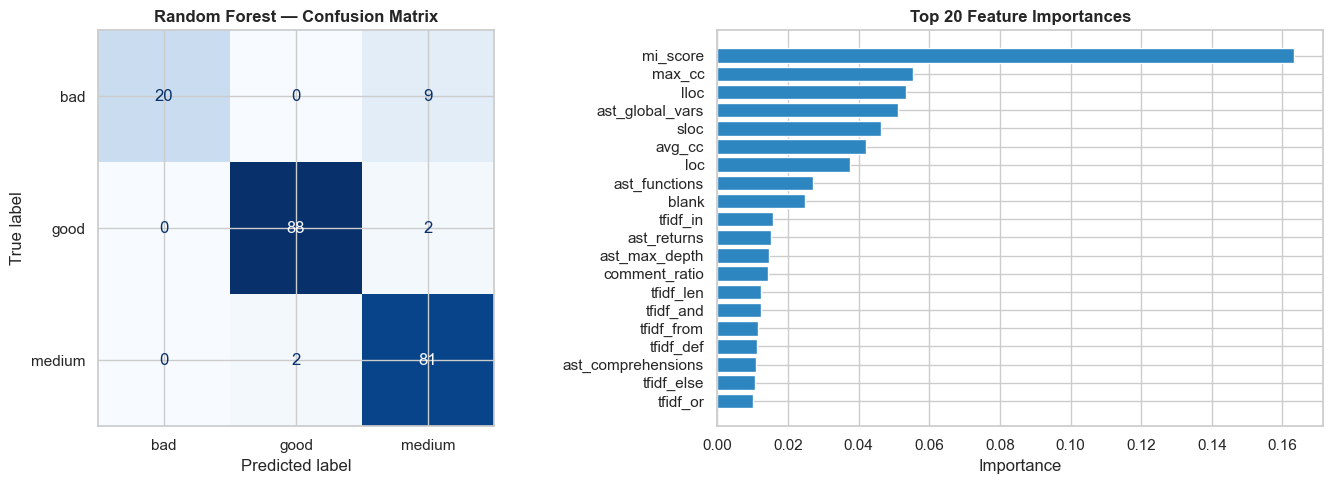

Top 10 most important features:
  mi_score                           : 0.1633
  max_cc                             : 0.0555
  lloc                               : 0.0535
  ast_global_vars                    : 0.0510
  sloc                               : 0.0464
  avg_cc                             : 0.0422
  loc                                : 0.0376
  ast_functions                      : 0.0270
  blank                              : 0.0248
  tfidf_in                           : 0.0158


In [12]:
# Confusion matrix — RF
from sympy import rf


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Random Forest — Confusion Matrix", fontweight="bold")

# Feature importances (top 20)
importances = random_forest.feature_importances_
feat_names  = pd.read_csv(X_TRAIN_CSV).columns.tolist()
top_idx     = np.argsort(importances)[::-1][:20]
top_imp     = importances[top_idx]
top_names   = [feat_names[i] for i in top_idx]

axes[1].barh(top_names[::-1], top_imp[::-1], color="#2E86C1", edgecolor="white")
axes[1].set_title("Top 20 Feature Importances", fontweight="bold")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/rf_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("Top 10 most important features:")
for name, imp in zip(top_names[:10], top_imp[:10]):
    print(f"  {name:<35}: {imp:.4f}")

---
## Baseline Model: Gradient Boosting (GBM)

Gradient Boosting builds trees sequentially, each correcting the errors of the previous one. It often outperforms Random Forest on structured tabular data but is slower to train.


In [17]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    min_samples_split=4,
    #help prevent overfitting
    subsample=0.8,
    random_state=RANDOM_STATE)
gradient_boosting_model.fit(X_train, y_train)
y_pred_gb = gradient_boosting_model.predict(X_test)
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb, average="weighted")
print(f"Gradient Boosting Accuracy: {gb_accuracy:.4f}")
print("Gradient Boosting Classification Report:")
print(classification_report(y_test, y_pred_gb,target_names=LABELS))


Gradient Boosting Accuracy: 1.0000
Gradient Boosting Classification Report:
              precision    recall  f1-score   support

         bad       1.00      1.00      1.00        29
        good       1.00      1.00      1.00        90
      medium       1.00      1.00      1.00        83

    accuracy                           1.00       202
   macro avg       1.00      1.00      1.00       202
weighted avg       1.00      1.00      1.00       202



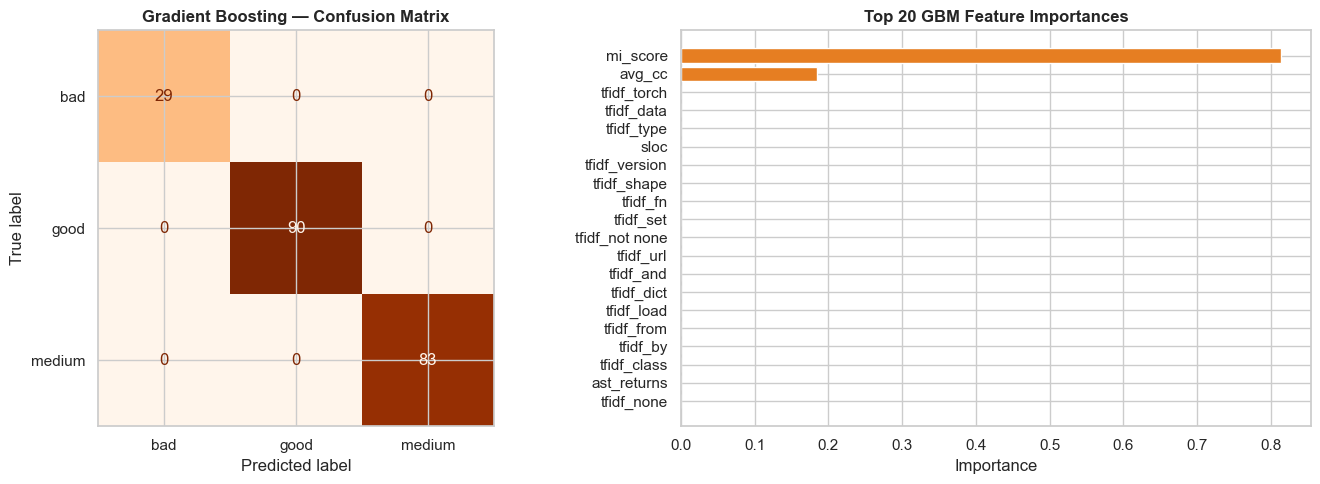

In [16]:
# Confusion matrix — GBM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_gbm = confusion_matrix(y_test, y_pred_gb)
ConfusionMatrixDisplay(cm_gbm, display_labels=LABELS).plot(
    ax=axes[0], colorbar=False, cmap="Oranges")
axes[0].set_title("Gradient Boosting — Confusion Matrix", fontweight="bold")

# GBM feature importances
gbm_imp    = gradient_boosting_model.feature_importances_
top_idx_g  = np.argsort(gbm_imp)[::-1][:20]
top_imp_g  = gbm_imp[top_idx_g]
top_names_g= [feat_names[i] for i in top_idx_g]

axes[1].barh(top_names_g[::-1], top_imp_g[::-1], color="#E67E22", edgecolor="white")
axes[1].set_title("Top 20 GBM Feature Importances", fontweight="bold")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/gbm_results.png", dpi=150, bbox_inches="tight")
plt.show()

Model                       Accuracy   F1 (weighted)
----------------------------------------------------
Random Forest                 0.9356          0.9332
Gradient Boosting             1.0000          1.0000


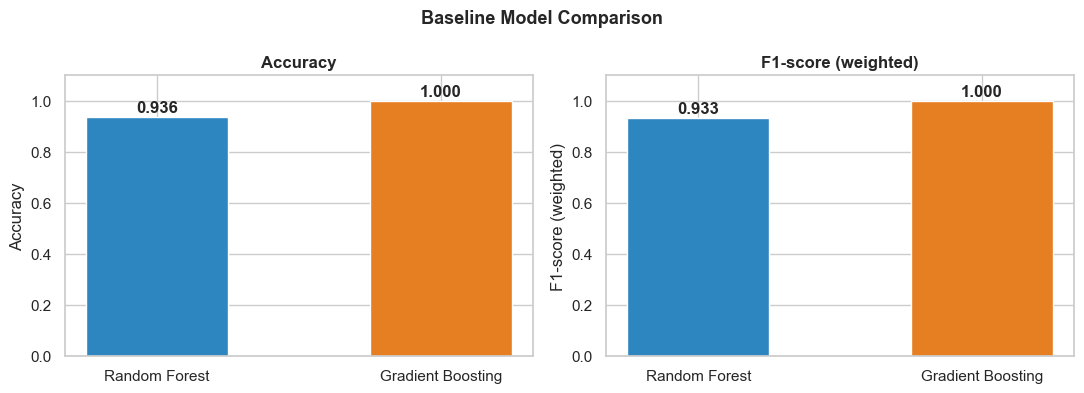

In [18]:
results = {
    "Random Forest":       {"acc": random_forest_accuracy,  "f1": random_forest_f1},
    "Gradient Boosting":   {"acc": gb_accuracy, "f1": gb_f1},
}

print(f"{'Model':<25} {'Accuracy':>10} {'F1 (weighted)':>15}")
print("-" * 52)
for name, m in results.items():
    print(f"{name:<25} {m['acc']:>10.4f} {m['f1']:>15.4f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
model_names = list(results.keys())
colors_bar  = ["#2E86C1", "#E67E22"]

for ax, metric, title in zip(axes, ["acc", "f1"], ["Accuracy", "F1-score (weighted)"]):
    vals = [results[m][metric] for m in model_names]
    bars = ax.bar(model_names, vals, color=colors_bar, edgecolor="white", width=0.5)
    ax.set_ylim(0, 1.1)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(title)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", fontweight="bold")

plt.suptitle("Baseline Model Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/baseline_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## Deep Model: 1D CNN 

A 1D Convolutional Neural Network treats the feature vector as a sequence and learns local patterns across groups of features. This is particularly effective when TF-IDF token features are adjacent the CNN can detect co-occurring vocabulary patterns that signal quality.



In [21]:

def cnn_architecture(n_features, n_classes):
    input = keras.Input(shape=(n_features,), name="features")
    x = layers.Reshape((n_features, 1))(input)
    # Conv layers 1
    x = layers.Conv1D(64, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPool1D(pool_size=2)(x)
    # Conv layers 2
    x = layers.Conv1D(128, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPool1D(pool_size=2)(x)
    # Conv layers 3
    x = layers.Conv1D(256, kernel_size=3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.GlobalMaxPooling1D()(x)
    # Dense layers
    x = layers.Dense(128, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    output = layers.Dense(n_classes, activation="softmax", name="output")(x)
    model = keras.Model(inputs=input, outputs=output, name="CodeQualityCNN")
    return model

cnn_model = cnn_architecture(N_FEATURES, N_CLASSES)
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()

Model: "CodeQualityCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 226)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 226, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 226, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 226, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 226, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 113, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 113, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 113, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 113, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 56, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 56, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,659 (651.01 KB)

 Trainable params: 165,763 (647.51 KB)

 Non-trainable params: 896 (3.50 KB)

In [22]:
cnn_callback =[
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)
] 
cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=cnn_callback,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.3950 - loss: 1.9079 - val_accuracy: 0.4534 - val_loss: 1.1888 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5008 - loss: 1.1847 - val_accuracy: 0.4286 - val_loss: 1.1988 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5179 - loss: 1.0940 - val_accuracy: 0.5590 - val_loss: 1.1520 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5179 - loss: 1.0631 - val_accuracy: 0.6273 - val_loss: 1.1151 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5459 - loss: 1.0462 - val_accuracy: 0.6398 - val_loss: 1.0900 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.5863 - loss: 0.9537 - val_accuracy: 0.6087 - val_loss: 1.0214 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5754 - loss: 0.9269 - 

In [23]:
y_pred_cnn_prob = cnn_model.predict(X_test)
y_pred_cnn = np.argmax(y_pred_cnn_prob, axis=1)
cnn_accuracy = accuracy_score(y_test, y_pred_cnn)
cnn_f1 = f1_score(y_test, y_pred_cnn, average="weighted")
print(f"CNN Accuracy: {cnn_accuracy:.4f}")
print(f"CNN F1 Score: {cnn_f1:.4f}")
print("CNN Classification Report:")
print(classification_report(y_test, y_pred_cnn,target_names=LABELS))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step
CNN Accuracy: 0.9554
CNN F1 Score: 0.9551
CNN Classification Report:
              precision    recall  f1-score   support

         bad       0.96      0.83      0.89        29
        good       1.00      0.97      0.98        90
      medium       0.91      0.99      0.95        83

    accuracy                           0.96       202
   macro avg       0.96      0.93      0.94       202
weighted avg       0.96      0.96      0.96       202



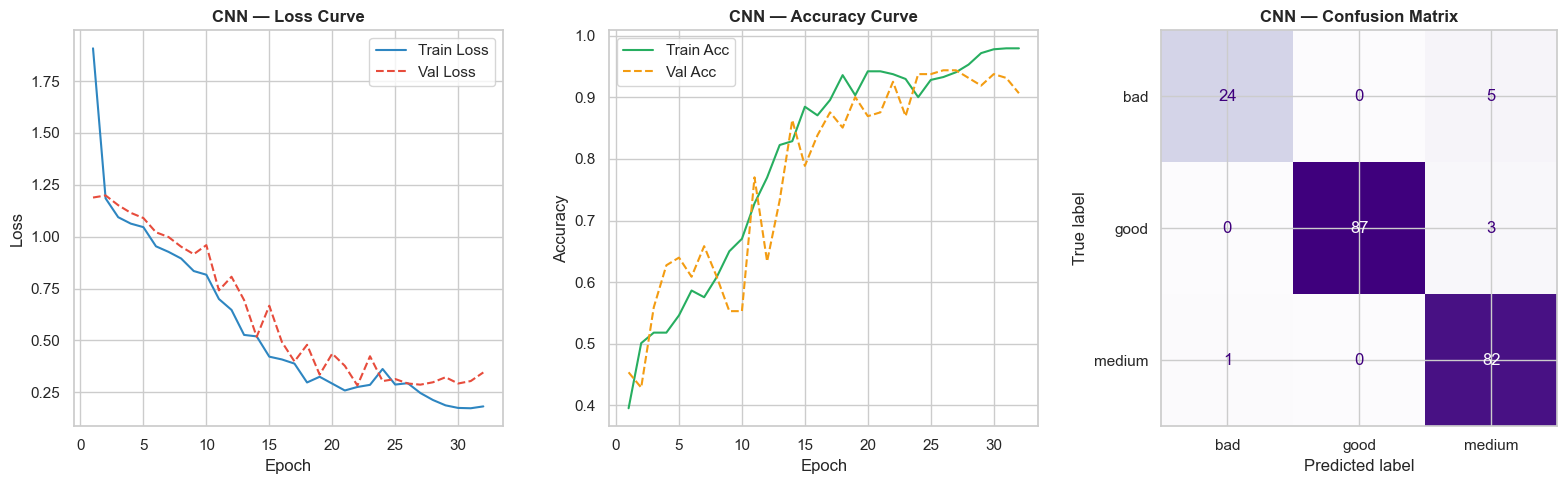

In [27]:
# Plot CNN training curves + confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

hist = cnn_history.history
epochs_ran = range(1, len(hist["loss"]) + 1)

# Loss curve
axes[0].plot(epochs_ran, hist["loss"],     label="Train Loss", color="#2E86C1")
axes[0].plot(epochs_ran, hist["val_loss"], label="Val Loss",   color="#E74C3C", linestyle="--")
axes[0].set_title("CNN — Loss Curve", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy curve
axes[1].plot(epochs_ran, hist["accuracy"],     label="Train Acc", color="#27AE60")
axes[1].plot(epochs_ran, hist["val_accuracy"], label="Val Acc",   color="#F39C12", linestyle="--")
axes[1].set_title("CNN — Accuracy Curve", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].legend()

# Confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_cnn),
                       display_labels=LABELS).plot(ax=axes[2], colorbar=False, cmap="Purples")
axes[2].set_title("CNN — Confusion Matrix", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cnn_results.png", dpi=150, bbox_inches="tight")
plt.show()

---
##  Deep Model: LSTM 

An LSTM (Long Short-Term Memory) network processes the feature vector as a sequence and can capture long-range dependencies between features. This is complementary to the CNN's local pattern detection.




In [28]:
def lstm_model(n_features, n_classes):
    input = keras.Input(shape=(n_features,), name="features")
    x = layers.Reshape((n_features, 1))(input)
    x = layers.LSTM(128, return_sequences=True)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LSTM(64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(0.001))(x)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(n_classes, activation="softmax", name="output")(x)
    model = keras.Model(inputs=input, outputs=output, name="CodeQualityLSTM")
    return model
lstm_model = lstm_model(N_FEATURES, N_CLASSES)
lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
lstm_model.summary()

Model: "CodeQualityLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)           │ (None, 226)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 226, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 226, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 226, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,091 (473.01 KB)

 Trainable params: 120,707 (471.51 KB)

 Non-trainable params: 384 (1.50 KB)

In [29]:
lstm_callback =[
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)
]
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=lstm_callback,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 234ms/step - accuracy: 0.4323 - loss: 1.3277 - val_accuracy: 0.5901 - val_loss: 1.1355 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - accuracy: 0.4868 - loss: 1.1400 - val_accuracy: 0.4845 - val_loss: 1.1287 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 191ms/step - accuracy: 0.5086 - loss: 1.0648 - val_accuracy: 0.5404 - val_loss: 1.1133 - learning_rate: 0.0010
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 190ms/step - accuracy: 0.5412 - loss: 1.0273 - val_accuracy: 0.5963 - val_loss: 1.0858 - learning_rate: 0.0010
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 194ms/step - accuracy: 0.4666 - loss: 1.1085 - val_accuracy: 0.4596 - val_loss: 1.1421 - learning_rate: 0.0010
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 201ms/step - accuracy: 0.4774 - loss: 1.1211 - val_accuracy: 0.4286 - val_loss: 1.1681 - learning_rate: 0.0010
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 185ms/step - accuracy: 0.4774 - loss: 1.

In [30]:
y_pred_lstm_prob = lstm_model.predict(X_test)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)
lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
lstm_f1 = f1_score(y_test, y_pred_lstm, average="weighted")
print(f"LSTM Accuracy: {lstm_accuracy:.4f}")
print(f"LSTM F1 Score: {lstm_f1:.4f}")
print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm,target_names=LABELS))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step
LSTM Accuracy: 0.4455
LSTM F1 Score: 0.2756
LSTM Classification Report:
              precision    recall  f1-score   support

         bad       0.00      0.00      0.00        29
        good       0.45      1.00      0.62        90
      medium       0.00      0.00      0.00        83

    accuracy                           0.45       202
   macro avg       0.15      0.33      0.21       202
weighted avg       0.20      0.45      0.28       202



In [39]:
# Collect all results
results["1D CNN"] = {"acc": cnn_accuracy,  "f1": cnn_f1,  "pred": y_pred_cnn}
results["LSTM"]   = {"acc": lstm_accuracy, "f1": lstm_f1, "pred": y_pred_lstm}
results["Random Forest"]["pred"]     = y_pred_rf
results["Gradient Boosting"]["pred"] = y_pred_gb

print(f"{'Model':<25} {'Accuracy':>10} {'F1 (weighted)':>15}")
print("=" * 52)
for name, m in results.items():
    marker = " ***** " if m["f1"] == max(r["f1"] for r in results.values()) else ""
    print(f"{name:<25} {m['acc']:>10.4f} {m['f1']:>15.4f}{marker}")

Model                       Accuracy   F1 (weighted)
Random Forest                 0.9356          0.9332
Gradient Boosting             1.0000          1.0000 ***** 
1D CNN                        0.9554          0.9551
LSTM                          0.4455          0.2756


In [43]:
# Save only the 1D CNN model

BEST_MODEL_PATH = f"{OUTPUT_DIR}/best_model_cnn.keras"

cnn_model.save(BEST_MODEL_PATH)

print(f"✅ Saved 1D CNN model → {BEST_MODEL_PATH}")

# Save metadata only for CNN
meta = {
    "model_name": "1D CNN",
    "f1": results["1D CNN"]["f1"],
    "accuracy": results["1D CNN"]["acc"],
    "n_features": int(N_FEATURES),
    "n_classes": int(N_CLASSES),
    "labels": LABELS
}

with open(f"{OUTPUT_DIR}/model_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"✅ Metadata saved → {OUTPUT_DIR}/model_metadata.json")

✅ Saved 1D CNN model → output/best_model_cnn.keras
✅ Metadata saved → output/model_metadata.json
